<h3>MUHAMMAD AFIQ DANIAL BIN ROZAIDIE (A23CS0117)</h3>

# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [2]:
#Write your code here
import pandas as pd
import numpy as np

# 1.
df_copy = pd.read_csv("Rainfall.csv")
df = df_copy.copy()

# 2.
print(df.head())

# 3.
print(df.isnull().sum())
num_columns = df.select_dtypes(include="number").columns
cat_columns = df.select_dtypes(include="object").columns

df[num_columns] = df[num_columns].fillna(df[num_columns].mean())
df[cat_columns] = df[cat_columns].fillna(df[cat_columns].mode().iloc[0])
print(df)

# 4.
summary =  df.describe()
print(summary)

  Region  Year Month   Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C  \
0  North  2023   Jan  StationA         56.2          9       12.1        2.5   
1  North  2023   Feb  StationA         72.1         12       14.7        3.0   
2  North  2023   Jan  StationB         60.5         10       11.2        1.8   
3  South  2023   Jan  StationC         81.0         13       19.6        7.2   
4  South  2023   Feb  StationC         63.4         11       20.1        7.7   

  UrbanRural  
0      Urban  
1      Urban  
2      Rural  
3      Urban  
4      Urban  
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64
  Region  Year Month   Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C  \
0  North  2023   Jan  StationA         56.2          9       12.1        2.5   
1  North  2023   Feb  StationA         72.1         12       14.7        3.0   
2  North  2023   Jan  S

## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [3]:
#Write your code here

total_rainfall = df.groupby('Station', as_index=False)['Rainfall_mm'].sum()
total_rainfall.columns = ['Station','Total_Rainfall_mm']

ave_rainyDays = df.groupby('Station', as_index=False)['RainyDays'].mean()
ave_rainyDays.columns = ['Station','Average_RainyDays']

ave_maxTemp = df.groupby('Station', as_index=False)['MaxTemp_C'].mean()
ave_maxTemp.columns = ['Station','Average_MaxTemp_C']

ave_minTemp = df.groupby('Station', as_index=False)['MinTemp_C'].mean()
ave_minTemp.columns = ['Station','Average_MinTemp_C']

df_merge = total_rainfall.merge(ave_rainyDays, on='Station') \
                         .merge(ave_maxTemp, on='Station') \
                         .merge(ave_minTemp, on='Station')
df_merge

,Station,Total_Rainfall_mm,Average_RainyDays,Average_MaxTemp_C,Average_MinTemp_C
0,StationA,128.3,10.5,13.40,2.75
1,StationB,122.0,10.5,13.10,2.50
2,StationC,144.4,12.0,19.85,7.45
3,StationD,105.3,9.0,16.65,5.90
4,StationE,161.6,12.5,17.50,5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [4]:
#Write your code here

total_rainfall_ru = df.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum()
ave_rainyDays_ru = df.groupby(['Region', 'UrbanRural'])['RainyDays'].mean()
ave_maxTemp_ru = df.groupby(['Region', 'UrbanRural'])['MaxTemp_C'].mean()

df_concat = pd.concat([total_rainfall_ru, ave_rainyDays_ru, ave_maxTemp_ru], axis=1) # concatenate along columns
df_concat.columns = (['Total_Rainfall_mm', 'Average_RainyDays', 'Average_MaxTemp_C'])

df_concat

Total_Rainfall_mm  Average_RainyDays  Average_MaxTemp_C
Region UrbanRural                                                         
East   Rural                   105.3                9.0              16.65
North  Rural                   122.0               10.5              13.10
       Urban                   128.3               10.5              13.40
South  Urban                   144.4               12.0              19.85
West   Urban                   161.6               12.5              17.50

3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [5]:
#Write your code here

total_rainfall = df.groupby(['Month', 'Region'])['Rainfall_mm'].sum()
mean_rainfall = df.groupby(['Month', 'Region'])['Rainfall_mm'].mean()
max_rainfall = df.groupby(['Month', 'Region'])['Rainfall_mm'].max()
min_rainfall = df.groupby(['Month', 'Region'])['Rainfall_mm'].min()

df_monthlyRegion = pd.concat([total_rainfall, mean_rainfall, max_rainfall, min_rainfall], axis=1)
df_monthlyRegion.columns = ['Total_Rainfall_mm', 'Mean_Rainfall_mm', 'Max_Rainfall_mm', 'Min_Rainfall_mm']

df_monthlyRegion

Total_Rainfall_mm  Mean_Rainfall_mm  Max_Rainfall_mm  \
Month Region                                                         
Feb   East                 59.6             59.60             59.6   
      North                72.1             72.10             72.1   
      South                63.4             63.40             63.4   
      West                 84.2             84.20             84.2   
Jan   East                 45.7             45.70             45.7   
      North               116.7             58.35             60.5   
      South                81.0             81.00             81.0   
      West                 77.4             77.40             77.4   
Mar   North                61.5             61.50             61.5   

              Min_Rainfall_mm  
Month Region                   
Feb   East               59.6  
      North              72.1  
      South              63.4  
      West               84.2  
Jan   East               45.7  
      North              56.2  
      South              81.0  
      West               77.4  
Mar   North              61.5

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [6]:
#Write your code here

month, region = df_monthlyRegion['Total_Rainfall_mm'].idxmax()

print(f"Highest Recorded Rainfall: {month} and {region}")

Highest Recorded Rainfall: Jan and North


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [7]:
#Write your code here

total_rainfall = df.groupby(['Year', 'UrbanRural'])['Rainfall_mm'].sum()
max_rainfall = df.groupby(['Year', 'UrbanRural'])['Rainfall_mm'].max()
min_rainfall = df.groupby(['Year', 'UrbanRural'])['Rainfall_mm'].min()

df_yearly = pd.concat([total_rainfall, max_rainfall, min_rainfall], axis=1)
df_yearly.columns = ['Total_Rainfall_mm', 'Max_Rainfall_mm', 'Min_Rainfall_mm']

df_yearly

Total_Rainfall_mm  Max_Rainfall_mm  Min_Rainfall_mm
Year UrbanRural                                                     
2023 Rural                   227.3             61.5             45.7
     Urban                   434.3             84.2             56.2

6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [8]:
#Write your code here

avg_maxTemp = df.groupby(['Region', 'Month'])['MaxTemp_C'].mean()
avg_minTemp= df.groupby(['Region', 'Month'])['MinTemp_C'].mean()

df_monthlyTemp = pd.concat([avg_maxTemp, avg_minTemp], axis=1)
df_monthlyTemp.columns = ['Avg_MaxTemp_C', 'Avg_MinTemp_C']

df_monthlyTemp

Avg_MaxTemp_C  Avg_MinTemp_C
Region Month                              
East   Feb            17.90           6.20
       Jan            15.40           5.60
North  Feb            14.70           3.00
       Jan            11.65           2.15
       Mar            15.00           3.20
South  Feb            20.10           7.70
       Jan            19.60           7.20
West   Feb            18.20           5.30
       Jan            16.80           4.90

## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



In [9]:
import matplotlib.pyplot as plt

In [10]:
df_concat

Total_Rainfall_mm  Average_RainyDays  Average_MaxTemp_C
Region UrbanRural                                                         
East   Rural                   105.3                9.0              16.65
North  Rural                   122.0               10.5              13.10
       Urban                   128.3               10.5              13.40
South  Urban                   144.4               12.0              19.85
West   Urban                   161.6               12.5              17.50

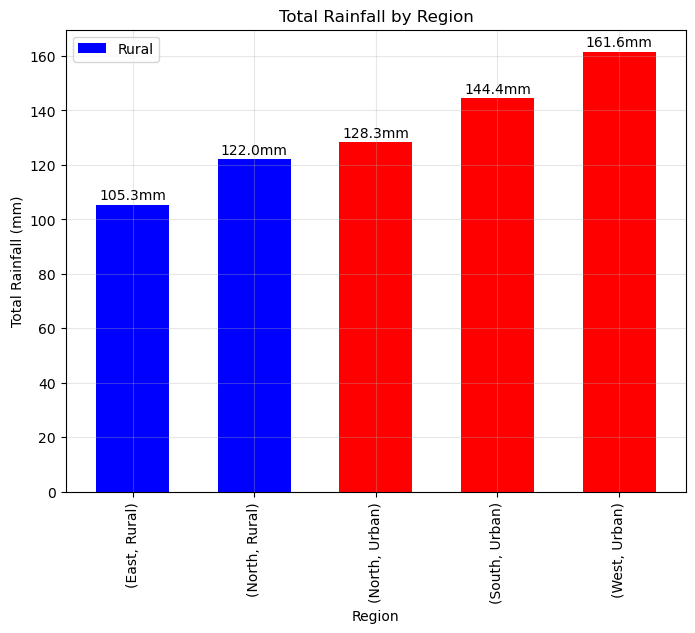

In [11]:
# Add colors for Urban/Rural
colors = ['blue' if 'Rural' in str(idx) else 'red' for idx in df_concat.index]
ax = df_concat['Total_Rainfall_mm'].plot(kind='bar', figsize=(8, 6), width=0.6, color=colors)

# Add value labels
for i, v in enumerate(df_concat['Total_Rainfall_mm']):
    ax.text(i, v + 2, f'{v:.1f}mm', ha='center')

# Complete labels and title
ax.set_xlabel('Region')  # Missing x-axis label
ax.set_ylabel('Total Rainfall (mm)')
ax.set_title('Total Rainfall by Region')
ax.grid(True, alpha=0.3)

# Add legend to show color coding
ax.legend(['Rural', 'Urban'], loc='upper left')

plt.show()
plt.savefig('bar_chart.png')
plt.close()

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



In [12]:
mean_rainfall_ms = df.groupby(['Month', 'Station'])['Rainfall_mm'].mean().to_frame('Average_Rainfall_mm')
df_plot = mean_rainfall_ms.unstack('Station')
df_plot.columns = df_plot.columns.get_level_values(1)
df_plot

Station,StationA,StationB,StationC,StationD,StationE
Month,,,,,
Feb,72.1,NaN,63.4,59.6,84.2
Jan,56.2,60.5,81.0,45.7,77.4
Mar,NaN,61.5,NaN,NaN,NaN


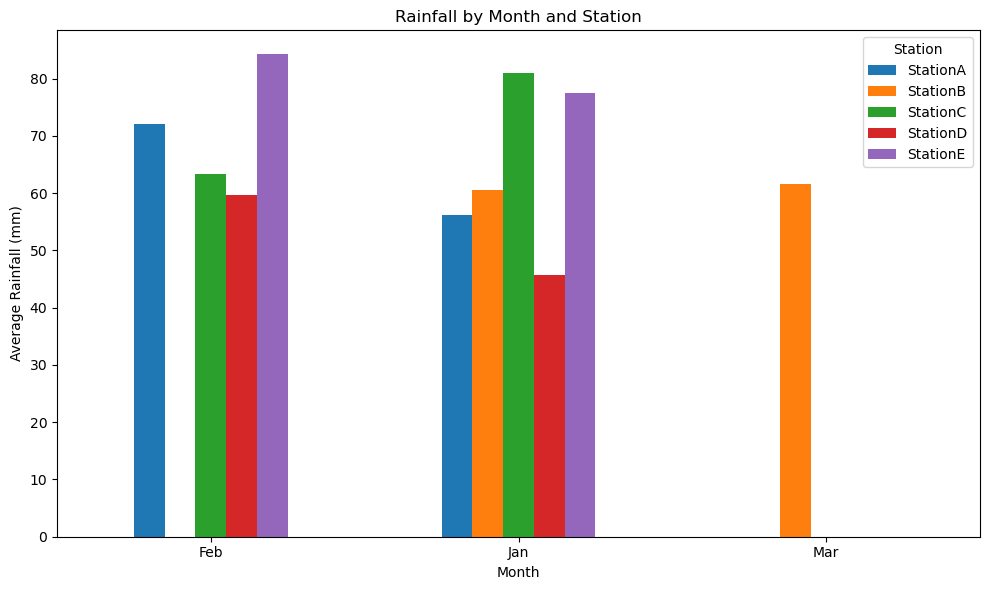

In [13]:
#Write your code here
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Rainfall by Month and Station')
plt.ylabel('Average Rainfall (mm)')
plt.xlabel('Month')
plt.xticks(rotation=0)
plt.legend(title='Station', loc='upper right')
plt.tight_layout()
plt.show()
plt.savefig('groupbar_chart.png')
plt.close()

3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



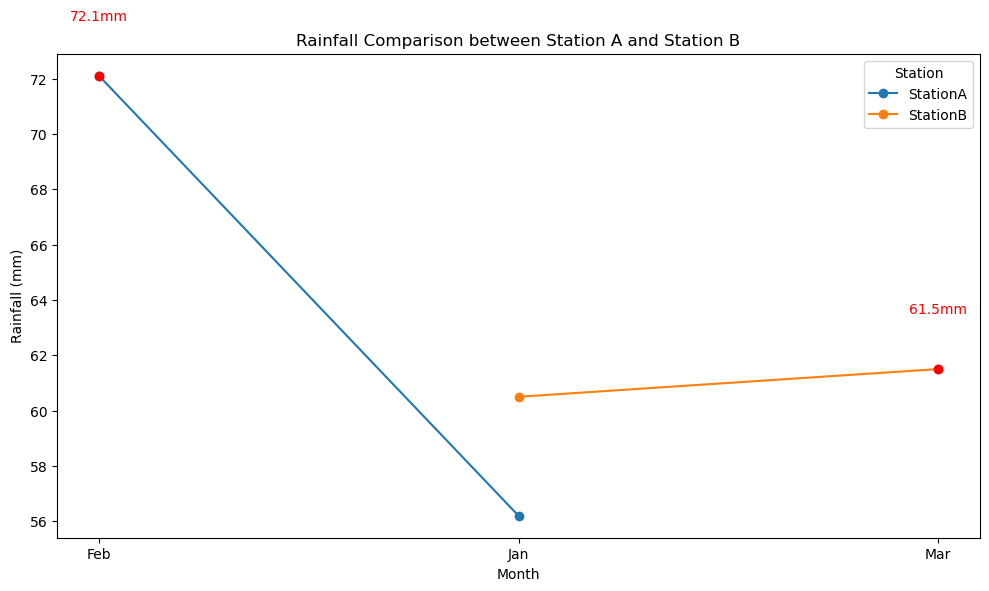

In [14]:
#Write your code here

df_selected = df_plot[['StationA', 'StationB']]

plt.figure(figsize=(10, 6))
for station in df_selected.columns:
    plt.plot(df_selected.index, df_selected[station], marker='o', label=station)
    # highlight the highest rainfall month
    max_month = df_selected[station].idxmax()
    max_value = df_selected[station].max()
    plt.plot(max_month, max_value, 'ro')  # red dot for max value
    plt.text(max_month, max_value + 2, f'{max_value:.1f}mm', ha='center', color='red')

plt.title('Rainfall Comparison between Station A and Station B')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.legend(title = 'Station')
plt.tight_layout()
plt.show()
plt.savefig('line_plot.png')
plt.close()

4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



In [15]:
df_concat
df_boxplot = df_concat.unstack()
df_boxplot = df_boxplot.drop(['Average_RainyDays', 'Average_MaxTemp_C'], axis=1)
df_boxplot.columns = df_boxplot.columns.get_level_values(1)
df_boxplot

UrbanRural,Rural,Urban
Region,,
East,105.3,NaN
North,122.0,128.3
South,NaN,144.4
West,NaN,161.6


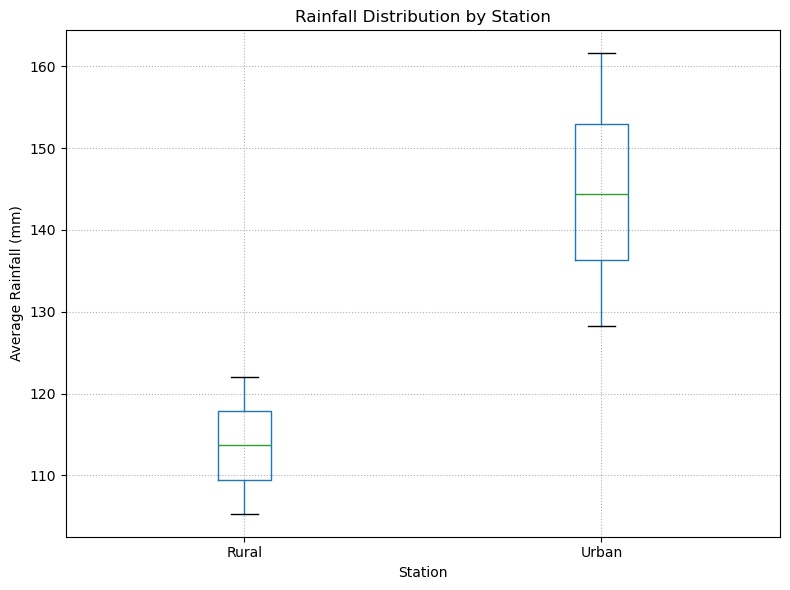

In [16]:
#Write your code here

plt.figure(figsize=(8, 6))
df_boxplot.boxplot()

# Step 3: Customize
plt.title('Rainfall Distribution by Station')
plt.ylabel('Average Rainfall (mm)')
plt.xlabel('Station')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()
plt.savefig('box_plot.png')
plt.close()


5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



In [17]:
# Create a DataFrame showing the relationship between rainfall and max temperature, with region info
df_scatter = df[['Region', 'Rainfall_mm', 'MaxTemp_C']].copy()
df_scatter

,Region,Rainfall_mm,MaxTemp_C
0,North,56.2,12.1
1,North,72.1,14.7
2,North,60.5,11.2
3,South,81.0,19.6
4,South,63.4,20.1
5,East,45.7,15.4
6,East,59.6,17.9
7,West,77.4,16.8
8,West,84.2,18.2
9,North,61.5,15.0


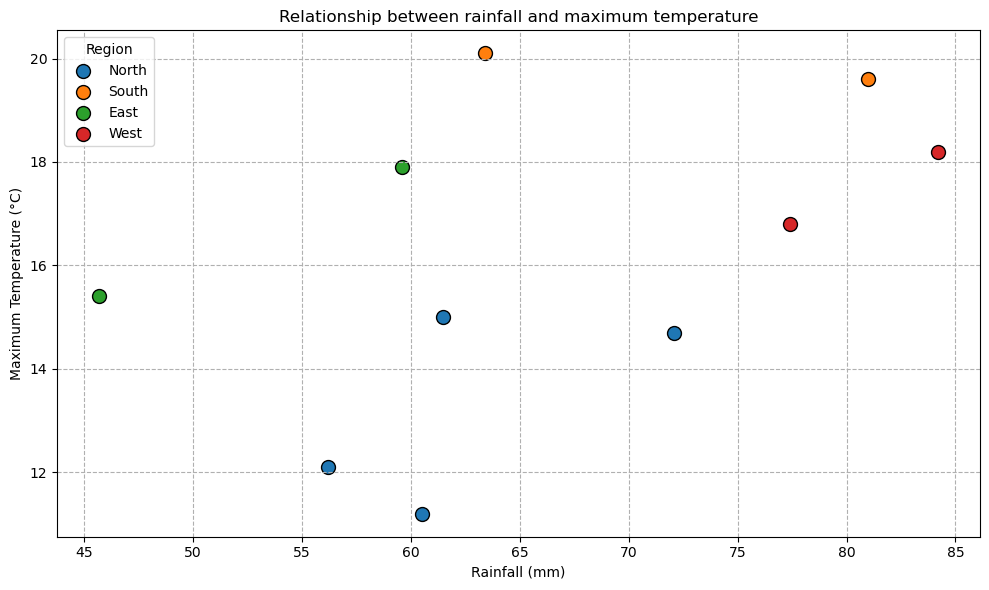

In [25]:
#Write your code here

plt.figure(figsize=(10,6))

for region in df_scatter['Region'].unique():
    subset = df_scatter[df_scatter['Region'] == region]
    plt.scatter(subset['Rainfall_mm'], subset['MaxTemp_C'], label=region, s=100, edgecolors='black')
    
    
plt.title('Relationship between rainfall and maximum temperature')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Maximum Temperature (°C)')
plt.legend(title='Region', loc='upper left')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()
plt.savefig('scatter_plot.png')
plt.close()


6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



In [19]:
df_heatmap = df_monthlyRegion.copy()
df_heatmap = df_heatmap.drop(columns=['Total_Rainfall_mm', 'Max_Rainfall_mm', 'Min_Rainfall_mm'])
df_heatmap = df_heatmap.reset_index()
df_heatmap

,Month,Region,Mean_Rainfall_mm
0,Feb,East,59.60
1,Feb,North,72.10
2,Feb,South,63.40
3,Feb,West,84.20
4,Jan,East,45.70
5,Jan,North,58.35
6,Jan,South,81.00
7,Jan,West,77.40
8,Mar,North,61.50


  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 'semi-expanded', 'expanded', 'ext

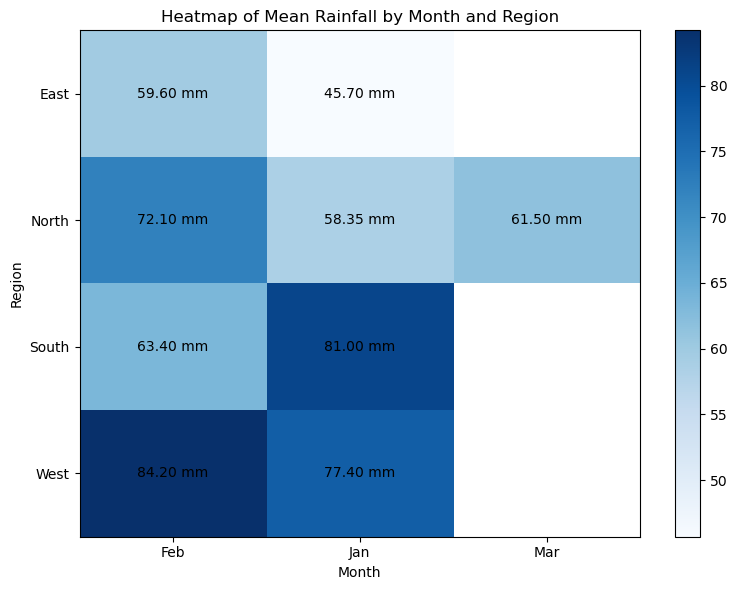

In [20]:
#Write your code here

# Pivot the DataFrame to get Regions as rows and Months as columns
heatmap_data = df_heatmap.pivot(index='Region', columns='Month', values='Mean_Rainfall_mm')

fig, ax = plt.subplots(figsize=(8, 6))
c = ax.imshow(heatmap_data.values, cmap='Blues', aspect='auto')

months = heatmap_data.columns
regions = heatmap_data.index

# Annotate each cell with the rainfall value
for r in range(len(regions)):
    for m in range(len(months)):
        val = heatmap_data.iloc[r, m]
        if not pd.isna(val):
            ax.text(m, r, f'{val:.2f} mm', ha='center', va='center', color='black')

ax.set_xticks(range(len(months)))
ax.set_yticks(range(len(regions)))
ax.set_xticklabels(months)
ax.set_yticklabels(regions)

plt.setp(ax.get_xticklabels())
plt.colorbar(c)

plt.title('Heatmap of Mean Rainfall by Month and Region')
plt.xlabel('Month')
plt.ylabel('Region')
plt.tight_layout()
plt.show()
fig.savefig('Heatmap.png')
plt.close(fig)

7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [21]:
#Write your code here



## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


In [22]:
df = df_monthlyRegion.copy()
df = df.drop(columns=['Mean_Rainfall_mm', 'Max_Rainfall_mm', 'Min_Rainfall_mm'])
df = df.reset_index()
df.drop(columns=['Month'], inplace=True)

df_unique = df.groupby('Region', as_index=False)['Total_Rainfall_mm'].sum()
df_unique

,Region,Total_Rainfall_mm
0,East,105.3
1,North,250.3
2,South,144.4
3,West,161.6


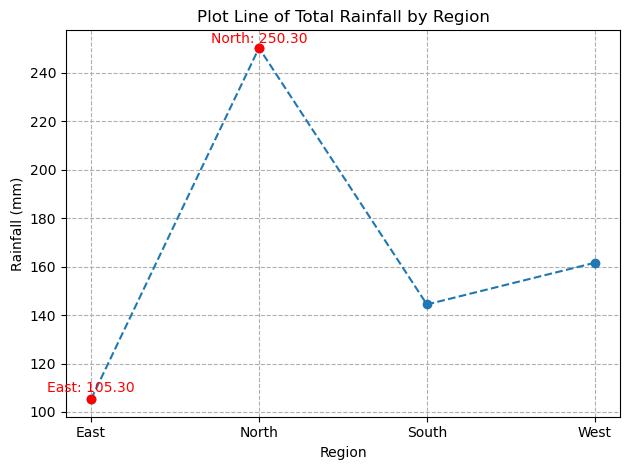

In [23]:
#Write your code here
plt.plot(df_unique['Region'], df_unique['Total_Rainfall_mm'], marker='o', linestyle='--')

max_value = df_unique['Total_Rainfall_mm'].max()
max_index = df_unique['Total_Rainfall_mm'].idxmax()
max_region = df_unique['Region'].iloc[max_index]

min_value = df_unique['Total_Rainfall_mm'].min()
min_index = df_unique['Total_Rainfall_mm'].idxmin()
min_region = df_unique['Region'].iloc[min_index]

plt.plot(max_region, max_value, 'ro')
plt.text(max_region, max_value + 2, f'{max_region}: {max_value:.2f}', color='red', ha='center')

plt.plot(min_region, min_value, 'ro')
plt.text(min_region, min_value + 3, f'{min_region}: {min_value:.2f}', color='red', ha='center')

plt.title('Plot Line of Total Rainfall by Region')
plt.xlabel('Region')
plt.ylabel('Rainfall (mm)')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


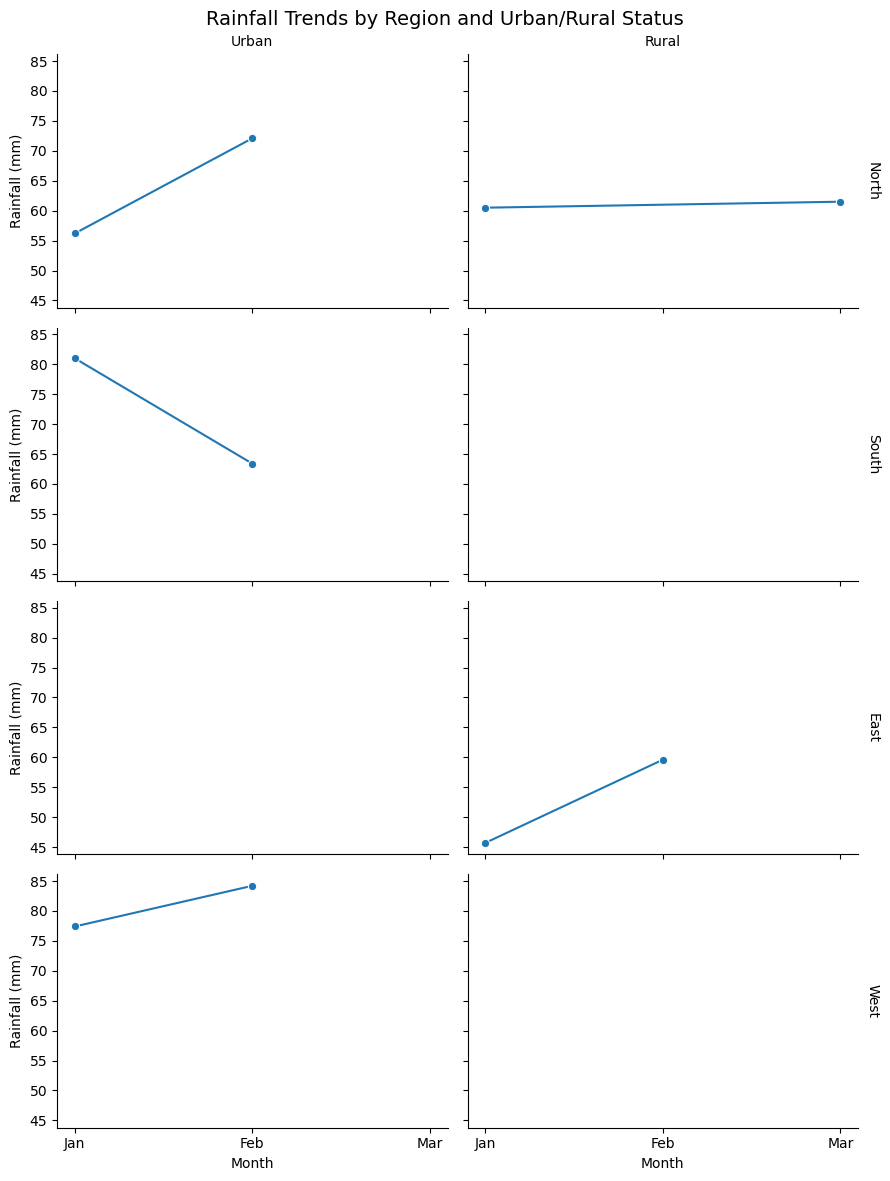

In [24]:
import seaborn as sns

#Write your code here
# Prepare data for facet grid: use the original df_copy to keep all columns
g = sns.FacetGrid(df_copy, row="Region", col="UrbanRural", margin_titles=True, height=3, aspect=1.5)
g.map_dataframe(sns.lineplot, x="Month", y="Rainfall_mm", marker="o")
g.set_axis_labels("Month", "Rainfall (mm)")
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Rainfall Trends by Region and Urban/Rural Status", fontsize=14)
plt.tight_layout()
plt.show()
g.savefig("facet_rainfall_trends.png")


3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here

Rainfall Trends: Monthly rainfall displayed clear variations across the year. Some months consistently showed higher rainfall, indicating possible seasonal patterns.

Regional Differences: Total rainfall varied significantly among the four regions. The South region recorded the highest total rainfall overall, while the East region experienced the lowest. This reflects possible geographical or climatic differences across the country.

Urban vs. Rural Patterns: The facet grid plots revealed different rainfall behaviors between urban and rural areas. In some regions, rural areas received more rainfall than urban areas, which could be influenced by land use, vegetation, or infrastructure.








